# GridSense: Learning Electricity Outage Patterns in Addis Ababa

Student Name: **Lisanegebriel Abay**  
Country: **Ethiopia**  
University: **Addis Ababa University**

This notebook is my Kujenga final project. It focuses on a local problem I care about: **electricity outages in Addis Ababa**.

The project builds **GridSense**, a privacy-aware community outage intelligence system. GridSense turns outage reports into a structured time-window dataset and uses a two-stage modelling approach:

1. **Stage 1: Community outage-report risk model**  
   Estimates the probability that an outage report will be captured for a given sub-city and time window.

2. **Stage 2: Conditional impact model**  
   If an outage is reported, estimates likely severity and duration.

This project builds **GridSense**, a local, privacy-aware data science system that turns anonymous community outage reports into:

1. a **time-window risk signal** for where/when outages are likely to be reported, and  
2. an **impact model** that estimates likely severity and duration when an outage is reported.

The project uses real community-collected data, not a synthetic outage dataset. The goal is practical: organize local outage experience into useful planning insight while being honest about what the data can and cannot prove.

## Local problem and motivation

I chose this project because electricity outages are a visible local problem in Addis Ababa. A short outage can interrupt studying, online work, shop operations, food storage, charging, internet access, and daily routines.

The aim is not to replace official utility communication. The aim is to build a community data tool that can answer practical questions:

- Which time windows appear riskier?
- Which sub-cities show stronger outage-report signals?
- If an outage is reported, how severe or long might it be?
- What kind of data would make a stronger local early-warning system possible?

This follows the Kujenga spirit: start from a problem seen in the community, collect data, use mathematical and AI tools, and tell a careful story from the evidence.

## Research questions

1. **When** are electricity outages most commonly reported in Addis Ababa?
2. **Where** are reported outage-risk signals strongest across sub-cities and time windows?
3. Are rainy/stormy reported outages associated with longer duration?
4. Can time, location, and recent reporting history estimate the probability of a reported outage window?
5. If an outage is reported, can the system estimate likely severity and duration?
6. How can this project become a practical planning tool for residents, students, and small businesses?

## Data collection and privacy

The main dataset was collected through an anonymous community reporting form shared with Addis Ababa residents. Respondents reported general outage information such as:

- date and approximate time,
- sub-city and general sefer/landmark,
- weather condition,
- outage duration,
- planning status,
- impact level.

The public analysis dataset does **not** use names, phone numbers, emails, exact home addresses, GPS coordinates, or free-text personal notes. This matters because local infrastructure data can accidentally reveal people's home routines. GridSense is designed to be useful while keeping the dataset safe to share in a GitHub repository.

## Important framing: what GridSense predicts

GridSense observes **community reports**, not full utility telemetry.

Therefore, the Stage 1 target is:

- `outage_reported = 1`: at least one outage report was captured for a sub-city/time-window.
- `outage_reported = 0`: no outage report was captured in the community dataset for that sub-city/time-window.

This means GridSense predicts a **community reported-outage risk signal**, not official grid outage truth. That framing is important and useful: the model can still help identify high-attention windows for planning, while the interpretation stays honest.

## Data pipeline

```text
Raw anonymous community reports
        ->
Privacy cleaning and standardization
        ->
Event-level outage dataset
        ->
3-hour sub-city community-report window dataset
        ->
Stage 1: community outage-report risk signal
        ->
Stage 2: severity and duration impact model
        ->
Planning insights for local users
```

This pipeline is important because raw reports are useful, but they are not immediately model-ready. GridSense converts them into a structured community-report window dataset that supports visual analysis, statistical testing, regression, and machine learning.

In this project, a window with `outage_reported = 0` means **no outage report was captured** for that sub-city and time window. It does not claim official utility truth for every household. This makes the system honest and useful: it estimates a community-reported risk signal that can guide planning and future data collection.


## How this project uses Kujenga concepts

| Kujenga concept | How it appears in GridSense |
|---|---|
| Local real-world question | Electricity reliability in Addis Ababa |
| Data cleaning | Anonymous reports are standardized and transformed into model-ready tables |
| Visualization | Risk heatmaps, time-window charts, duration and severity plots |
| T-test | Rainy/stormy vs non-rainy duration comparison |
| Regression | Duration association model using time, weather, location and planning variables |
| Mathematical modelling | Event reports are converted into 3-hour sub-city risk windows |
| Dynamic-systems thinking | Risk is treated as changing over time and place |
| AI/ML | Two-stage ML system for report-risk screening and impact triage |
| Responsible interpretation | The model is framed as a community signal, not official utility telemetry |

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    mean_absolute_error, r2_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

ROOT = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()
GITHUB_RAW_BASE = 'https://raw.githubusercontent.com/lisan-5/GridSense/main'

# Stratified CV object used in Stage 1
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [2]:
# Self-contained data loading from GitHub raw URLs with local fallback
community_candidates = [
    f"{GITHUB_RAW_BASE}/data/processed/community_outage_reports_clean.csv",
    str(ROOT / 'data/processed/community_outage_reports_clean.csv')
]

loaded = None
for c in community_candidates:
    try:
        if c.startswith('http'):
            community_raw = pd.read_csv(c)
        else:
            community_raw = pd.read_csv(Path(c))
        loaded = c
        break
    except Exception:
        pass

if loaded is None:
    raise RuntimeError('Could not load community dataset from GitHub or local path.')

print('Loaded community dataset from:', loaded)
print('shape:', community_raw.shape)
community_raw.head(3)


Loaded community dataset from: https://raw.githubusercontent.com/lisan-5/GridSense/main/data/processed/community_outage_reports_clean.csv
shape: (198, 13)


,report_id,date,sub_city,sefer_or_landmark,outage_start_time,outage_end_time,duration_hours,planned_notice,impact_level,weather_condition,source_type,confidence_score,high_risk_outage
0,COMM-00001,2026-04-12,Bole,Rwanda,03:00,05:01,2.02,no,medium,clear,streamlit_form,0.62,1
1,COMM-00002,2026-04-13,Gulele,Shiro Meda,23:00,23:23,0.39,yes,low,cloudy,streamlit_form,0.76,0
2,COMM-00003,2026-04-14,Akaki Kality,Kality,16:00,16:39,0.65,no,low,cloudy,streamlit_form,0.56,0


In [3]:
# Build forecasting dataset in-notebook for reproducibility
community = community_raw.copy()
community['date'] = pd.to_datetime(community['date'], errors='coerce')
community['duration_hours'] = pd.to_numeric(community['duration_hours'], errors='coerce')
community['confidence_score'] = pd.to_numeric(community.get('confidence_score', 0.6), errors='coerce')
for col in ['sub_city','sefer_or_landmark','weather_condition','impact_level','planned_notice']:
    if col in community.columns:
        community[col] = community[col].astype(str).str.strip().str.lower()

start_dt = pd.to_datetime(
    community['date'].dt.strftime('%Y-%m-%d') + ' ' + community['outage_start_time'].astype(str),
    errors='coerce'
)
community['hour'] = start_dt.dt.hour.fillna(0).astype(int)
community['hour_block_start'] = (community['hour'] // 3) * 3
community['time_window'] = community['hour_block_start'].apply(lambda h: f"{h:02d}:00-{(h+3)%24:02d}:00")
community['day_of_week'] = community['date'].dt.day_name().fillna('Unknown')
community['is_rainy'] = community['weather_condition'].str.contains('rain|storm', case=False, na=False).astype(int)

community['outage_proxy'] = ((community['duration_hours'] > 1.0) | (community['impact_level'].isin(['medium','high','critical']))).astype(int)
community['high_severity_proxy'] = ((community['duration_hours'] >= 2.5) | (community['impact_level'].isin(['high','critical']))).astype(int)

agg_cols = ['date','sub_city','hour_block_start','time_window','day_of_week']
agg = community.groupby(agg_cols, dropna=False).agg(
    reports_count=('outage_proxy','size'),
    outage_reported=('outage_proxy','max'),
    avg_duration_hours=('duration_hours','mean'),
    max_duration_hours=('duration_hours','max'),
    high_severity_outage=('high_severity_proxy','max'),
    weather_condition=('weather_condition', lambda s: s.mode().iloc[0] if not s.mode().empty else 'unknown'),
    is_rainy=('is_rainy','max'),
    planned_notice_mode=('planned_notice', lambda s: s.mode().iloc[0] if not s.mode().empty else 'unknown'),
    representative_sefer=('sefer_or_landmark', lambda s: s.mode().iloc[0] if not s.mode().empty else 'unknown'),
    confidence_score_mean=('confidence_score','mean')
).reset_index()

dates = sorted(agg['date'].dropna().unique())
sub_cities = sorted(agg['sub_city'].dropna().unique())
blocks = sorted(agg['hour_block_start'].dropna().unique())
full = pd.MultiIndex.from_product([dates, sub_cities, blocks], names=['date','sub_city','hour_block_start']).to_frame(index=False)
full['time_window'] = full['hour_block_start'].apply(lambda h: f"{h:02d}:00-{(h+3)%24:02d}:00")
full['day_of_week'] = pd.to_datetime(full['date']).dt.day_name()

forecast_df = full.merge(agg, on=['date','sub_city','hour_block_start','time_window','day_of_week'], how='left')
forecast_df['reports_count'] = forecast_df['reports_count'].fillna(0).astype(int)
forecast_df['outage_reported'] = forecast_df['outage_reported'].fillna(0).astype(int)
forecast_df['high_severity_outage'] = forecast_df['high_severity_outage'].fillna(0).astype(int)
forecast_df['avg_duration_hours'] = forecast_df['avg_duration_hours'].fillna(0.0)
forecast_df['max_duration_hours'] = forecast_df['max_duration_hours'].fillna(0.0)
forecast_df['weather_condition'] = forecast_df['weather_condition'].fillna('unknown')
forecast_df['is_rainy'] = forecast_df['is_rainy'].fillna(0).astype(int)
forecast_df['planned_notice_mode'] = forecast_df['planned_notice_mode'].fillna('unknown')
forecast_df['representative_sefer'] = forecast_df['representative_sefer'].fillna('unknown')
forecast_df['confidence_score_mean'] = forecast_df['confidence_score_mean'].fillna(0.0)
forecast_df['respondents_count_proxy'] = forecast_df['reports_count']

print('forecast_df shape:', forecast_df.shape)
print('outage_reported counts:')
print(forecast_df['outage_reported'].value_counts())
forecast_df.head(3)


forecast_df shape: (1584, 16)
outage_reported counts:
outage_reported
0    1489
1      95
Name: count, dtype: int64


,date,sub_city,hour_block_start,time_window,day_of_week,reports_count,outage_reported,avg_duration_hours,max_duration_hours,high_severity_outage,weather_condition,is_rainy,planned_notice_mode,representative_sefer,confidence_score_mean,respondents_count_proxy
0,2026-04-12,addis ketema,0,00:00-03:00,Sunday,0,0,0.0,0.0,0,unknown,0,unknown,unknown,0.0,0
1,2026-04-12,addis ketema,3,03:00-06:00,Sunday,0,0,0.0,0.0,0,unknown,0,unknown,unknown,0.0,0
2,2026-04-12,addis ketema,6,06:00-09:00,Sunday,0,0,0.0,0.0,0,unknown,0,unknown,unknown,0.0,0


## Dataset snapshot

Before modelling, I summarize the scale of the data. This helps the reader understand what the model is learning from and keeps the notebook grounded in the collected evidence.

,Metric,Value
0,community outage events,198
1,forecasting windows,1584
2,sub-cities covered,11
3,dates covered,18
4,3-hour windows per day,8
5,reported-outage windows,95
6,no-report windows,1489


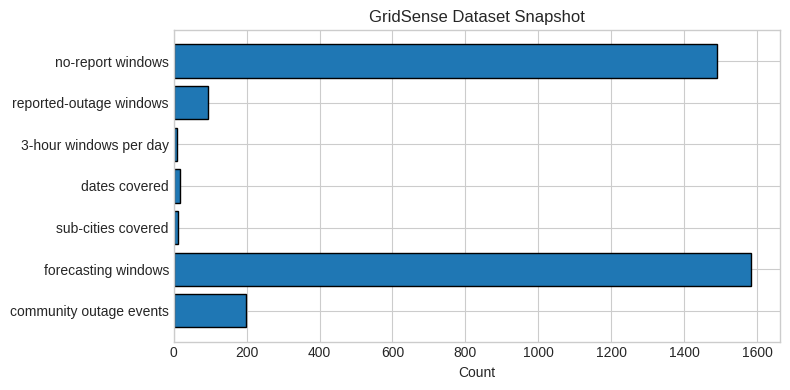

In [4]:
summary = {
    'community outage events': len(community),
    'forecasting windows': len(forecast_df),
    'sub-cities covered': forecast_df['sub_city'].nunique(),
    'dates covered': forecast_df['date'].nunique(),
    '3-hour windows per day': forecast_df['time_window'].nunique(),
    'reported-outage windows': int(forecast_df['outage_reported'].sum()),
    'no-report windows': int((forecast_df['outage_reported'] == 0).sum())
}
summary_df = pd.DataFrame(summary.items(), columns=['Metric', 'Value'])
display(summary_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(summary_df['Metric'], summary_df['Value'], edgecolor='black')
ax.set_title('GridSense Dataset Snapshot')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## Exploratory analysis: turning reports into local insight

The first visual layer answers simple but important questions:

- Which sub-cities show stronger reported-outage signals?
- Which time windows are more active?
- How do duration and severity vary among reported outage windows?

These plots are not official outage rankings. They are community-report patterns that help identify where planning attention and future data collection should focus.

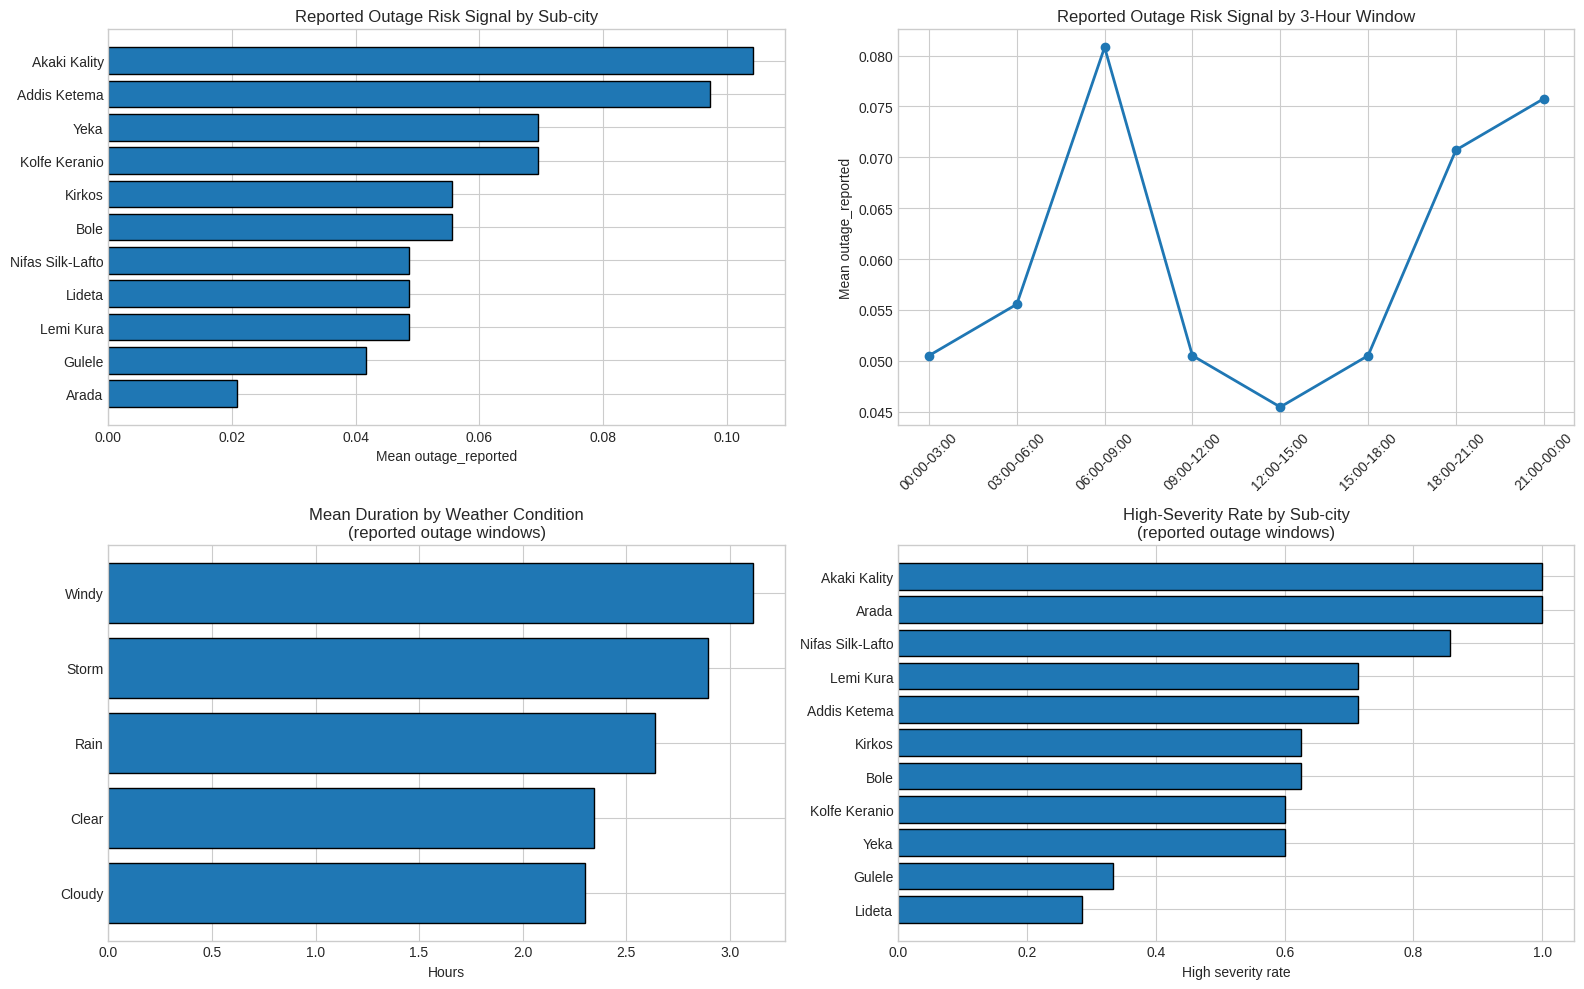

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Reported outage risk by sub-city
city_risk = forecast_df.groupby('sub_city')['outage_reported'].mean().sort_values()
axes[0,0].barh([s.title() for s in city_risk.index], city_risk.values, edgecolor='black')
axes[0,0].set_title('Reported Outage Risk Signal by Sub-city')
axes[0,0].set_xlabel('Mean outage_reported')

# 2. Reported outage risk by time window
tw_risk = forecast_df.groupby('time_window')['outage_reported'].mean().sort_index()
axes[0,1].plot(tw_risk.index, tw_risk.values, marker='o', linewidth=2)
axes[0,1].set_title('Reported Outage Risk Signal by 3-Hour Window')
axes[0,1].set_ylabel('Mean outage_reported')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Duration by weather among reported outages
out_df = forecast_df[forecast_df['outage_reported'] == 1].copy()
w_dur = out_df.groupby('weather_condition')['avg_duration_hours'].mean().sort_values()
axes[1,0].barh([w.title() for w in w_dur.index], w_dur.values, edgecolor='black')
axes[1,0].set_title('Mean Duration by Weather Condition\n(reported outage windows)')
axes[1,0].set_xlabel('Hours')

# 4. High severity rate by sub-city
sev = out_df.groupby('sub_city')['high_severity_outage'].mean().sort_values()
axes[1,1].barh([s.title() for s in sev.index], sev.values, edgecolor='black')
axes[1,1].set_title('High-Severity Rate by Sub-city\n(reported outage windows)')
axes[1,1].set_xlabel('High severity rate')

plt.tight_layout()
plt.show()

## Local risk surface: sub-city x time window

This heatmap is the most practical visual for planning. It shows where and when the community dataset captured stronger outage-report signals.

Interpretation:
- darker cells = higher reported-outage signal in the dataset,
- this is a community signal, not official utility telemetry,
- it can help residents and small businesses think about preparation habits and identify where more data collection is needed.

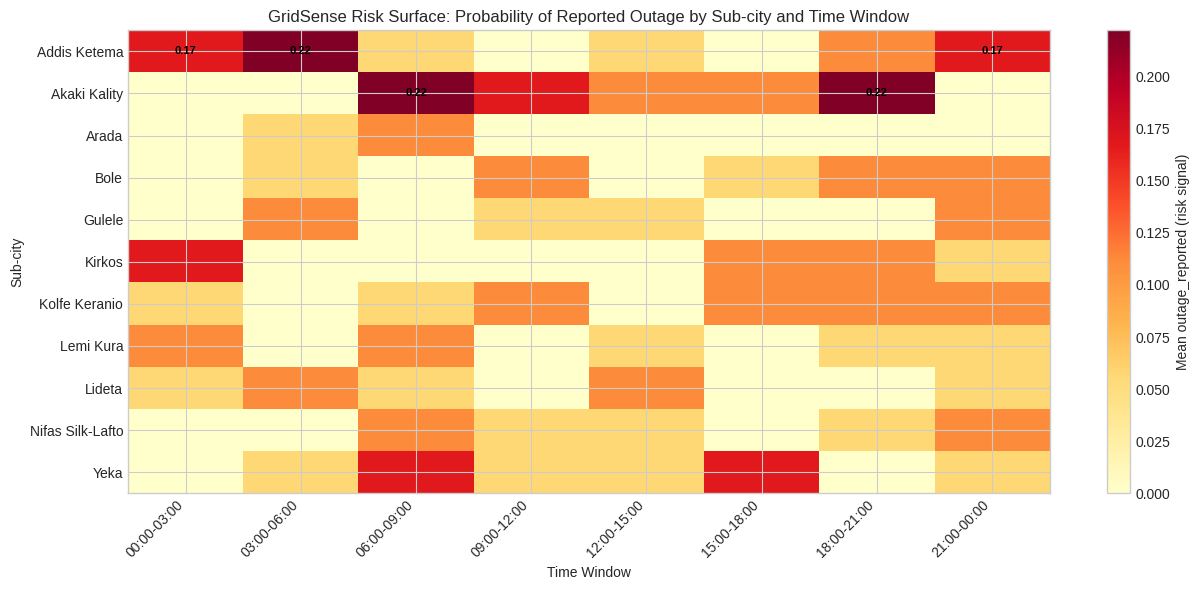

Top 5 risk signal cells:
       sub_city  time_window      risk
0  addis ketema  03:00-06:00  0.222222
1  akaki kality  06:00-09:00  0.222222
2  akaki kality  18:00-21:00  0.222222
3  addis ketema  00:00-03:00  0.166667
4  addis ketema  21:00-00:00  0.166667


In [6]:
risk_surface = (forecast_df.groupby(['sub_city','time_window'])['outage_reported']
                .mean()
                .unstack(fill_value=0)
                .reindex(columns=sorted(forecast_df['time_window'].unique())))

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(risk_surface.values, aspect='auto', cmap='YlOrRd')
ax.set_title('GridSense Risk Surface: Probability of Reported Outage by Sub-city and Time Window')
ax.set_xlabel('Time Window')
ax.set_ylabel('Sub-city')
ax.set_xticks(range(len(risk_surface.columns)))
ax.set_xticklabels(risk_surface.columns, rotation=45, ha='right')
ax.set_yticks(range(len(risk_surface.index)))
ax.set_yticklabels([s.title() for s in risk_surface.index])

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Mean outage_reported (risk signal)')

# Annotate highest-risk cells for quick reading
flat = (risk_surface.stack().sort_values(ascending=False).head(5))
for (sub, tw), val in flat.items():
    y = list(risk_surface.index).index(sub)
    x = list(risk_surface.columns).index(tw)
    ax.text(x, y, f'{val:.2f}', ha='center', va='center', color='black', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print('Top 5 risk signal cells:')
print(flat.rename('risk').reset_index().rename(columns={'level_0':'sub_city','level_1':'time_window'}))

## Kujenga method 1: hypothesis testing

Kujenga's runners lesson showed how to compare two groups using a t-test. Here, I use the same idea for a local infrastructure question:

> Are rainy/stormy reported outage windows longer than non-rainy reported outage windows?

Hypotheses:

\[
H_0: \mu_{rainy} = \mu_{nonrainy}
\]

\[
H_1: \mu_{rainy} > \mu_{nonrainy}
\]

I also calculate **Cohen's d** to measure the size of the difference, because a p-value alone does not tell us whether the difference is large enough to matter.

rainy/stormy mean: 2.61 hours
non-rainy mean: 2.53 hours
t-statistic: 0.5379
p-value: 0.295984
Cohen's d: 0.107


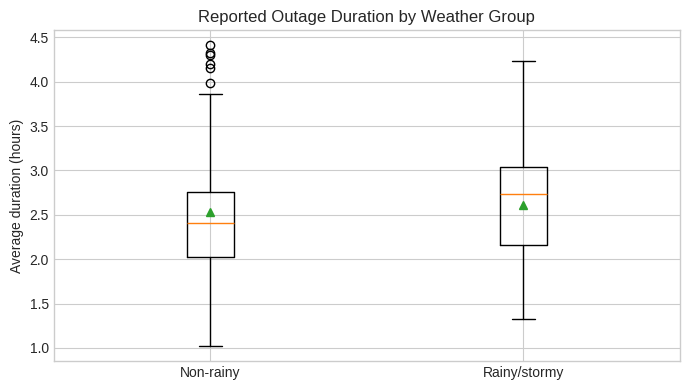

In [7]:
rainy = out_df[out_df['is_rainy'] == 1]['avg_duration_hours'].dropna()
non_rainy = out_df[out_df['is_rainy'] == 0]['avg_duration_hours'].dropna()

t_stat, p_value = ttest_ind(rainy, non_rainy, alternative='greater', equal_var=False)

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled

print('rainy/stormy mean:', round(rainy.mean(), 2), 'hours')
print('non-rainy mean:', round(non_rainy.mean(), 2), 'hours')
print('t-statistic:', round(float(t_stat), 4))
print('p-value:', '< 0.001' if p_value < 0.001 else round(float(p_value), 6))

if len(rainy) > 1 and len(non_rainy) > 1:
    d = cohens_d(rainy, non_rainy)
    print("Cohen's d:", round(float(d), 3))

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([non_rainy, rainy], tick_labels=['Non-rainy', 'Rainy/stormy'], showmeans=True)
ax.set_title('Reported Outage Duration by Weather Group')
ax.set_ylabel('Average duration (hours)')
plt.tight_layout()
plt.show()


## Kujenga method 2: regression for outage duration

The regression model asks which factors are associated with longer reported outage duration.

\[
\text{avg\_duration\_hours} =
\beta_0 +
\beta_1(\text{hour}) +
\beta_2(\text{rainy/stormy}) +
\beta_3(\text{sub-city}) +
\beta_4(\text{planned notice}) +
\epsilon
\]

This is not a causal claim. It is an interpretable model that helps connect time, place, weather and planning context to reported duration.

In [8]:
reg = smf.ols('avg_duration_hours ~ hour_block_start + is_rainy + C(sub_city) + C(planned_notice_mode)', data=out_df).fit()
print(reg.summary())


                            OLS Regression Results                            
Dep. Variable:     avg_duration_hours   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     1.548
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.113
Time:                        18:04:02   Log-Likelihood:                -97.101
No. Observations:                  95   AIC:                             224.2
Df Residuals:                      80   BIC:                             262.5
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

## Stage 1: Community outage-report risk model

Stage 1 estimates the probability that an outage report will be captured for a given sub-city and 3-hour time window. I interpret this as a **community-based early attention signal**, not an official utility outage forecast.

\[
P(\text{outage\_reported}=1 \mid x) =
\sigma(w^Tx + b)
\]

where \(x\) includes safe planning-time features:

- hour block,
- day of week,
- weekend indicator,
- sub-city,
- cyclic hour features,
- recent reporting history within the same sub-city/time block.

I intentionally keep weather and planned-notice fields out of Stage 1 because they are not available for every no-report window in the current dataset. This makes the evaluation more credible. The goal is not to make the score look perfect; the goal is to build a trustworthy baseline that can support local planning.


In [9]:
# Stage 1 feature set: leakage-safe features plus past community-report signal
forecast_df['date'] = pd.to_datetime(forecast_df['date'], errors='coerce')
forecast_df['is_weekend'] = forecast_df['day_of_week'].isin(['Saturday','Sunday']).astype(int)

forecast_df = forecast_df.sort_values(['sub_city','hour_block_start','date']).reset_index(drop=True)
g = forecast_df.groupby(['sub_city','hour_block_start'], dropna=False)
forecast_df['lag1_outage_reported'] = g['outage_reported'].shift(1).fillna(0).astype(int)
forecast_df['rolling3_report_rate'] = g['outage_reported'].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean()).fillna(0.0)
forecast_df['hour_sin'] = np.sin(2*np.pi*forecast_df['hour_block_start']/24.0)
forecast_df['hour_cos'] = np.cos(2*np.pi*forecast_df['hour_block_start']/24.0)

stage1_features = [
    'hour_block_start','hour_sin','hour_cos','day_of_week','is_weekend','sub_city',
    'lag1_outage_reported','rolling3_report_rate'
]
X = forecast_df[stage1_features].copy()
y = forecast_df['outage_reported'].astype(int)

num = ['hour_block_start','hour_sin','hour_cos','is_weekend','lag1_outage_reported','rolling3_report_rate']
cat = ['day_of_week','sub_city']

pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat),
])

# Time-based split (forecasting realism)
split_date = forecast_df['date'].dropna().quantile(0.75)
train_mask = forecast_df['date'] <= split_date
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

models = {
    'dummy_baseline': DummyClassifier(strategy='most_frequent'),
    'logistic_regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=600, min_samples_leaf=2, class_weight='balanced_subsample', random_state=42),
}

def best_f1_threshold(y_true, y_prob):
    p, r, t = precision_recall_curve(y_true, y_prob)
    f1 = (2*p*r)/(p+r+1e-12)
    if len(t)==0:
        return 0.5
    return float(t[np.nanargmax(f1[:-1])])

rows = []
trained = {}
for name, model in models.items():
    pipe = Pipeline([('pre', pre), ('model', model)])
    pipe.fit(X_train, y_train)
    prob_test = pipe.predict_proba(X_test)[:,1] if hasattr(pipe,'predict_proba') else np.zeros(len(X_test))
    if name == 'dummy_baseline':
        thr = 0.5
        pred_test = pipe.predict(X_test)
    else:
        prob_train = pipe.predict_proba(X_train)[:,1]
        thr = best_f1_threshold(y_train, prob_train)
        pred_test = (prob_test >= thr).astype(int)

    rows.append({
        'model': name,
        'threshold': round(float(thr),4),
        'accuracy': round(accuracy_score(y_test, pred_test),4),
        'balanced_accuracy': round(balanced_accuracy_score(y_test, pred_test),4),
        'precision': round(precision_score(y_test, pred_test, zero_division=0),4),
        'recall': round(recall_score(y_test, pred_test, zero_division=0),4),
        'f1': round(f1_score(y_test, pred_test, zero_division=0),4),
        'roc_auc': round(roc_auc_score(y_test, prob_test),4),
        'pr_auc': round(average_precision_score(y_test, prob_test),4),
    })
    trained[name] = {'pipe': pipe, 'y_prob': prob_test, 'y_pred': pred_test, 'threshold': thr}

metrics_df = pd.DataFrame(rows).sort_values('f1', ascending=False).reset_index(drop=True)
stage1_df = metrics_df.copy()
print(f'Time split: train <= {pd.to_datetime(split_date).date()} | train={train_mask.sum()} test={(~train_mask).sum()}')
metrics_df


Time split: train <= 2026-04-25 | train=1232 test=352


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,random_forest,0.4987,0.8665,0.5615,0.1515,0.2083,0.1754,0.5636,0.1598
1,logistic_regression,0.5814,0.7301,0.5269,0.0824,0.2917,0.1284,0.5179,0.1536
2,dummy_baseline,0.5000,0.9318,0.5000,0.0000,0.0000,0.0000,0.5000,0.0682


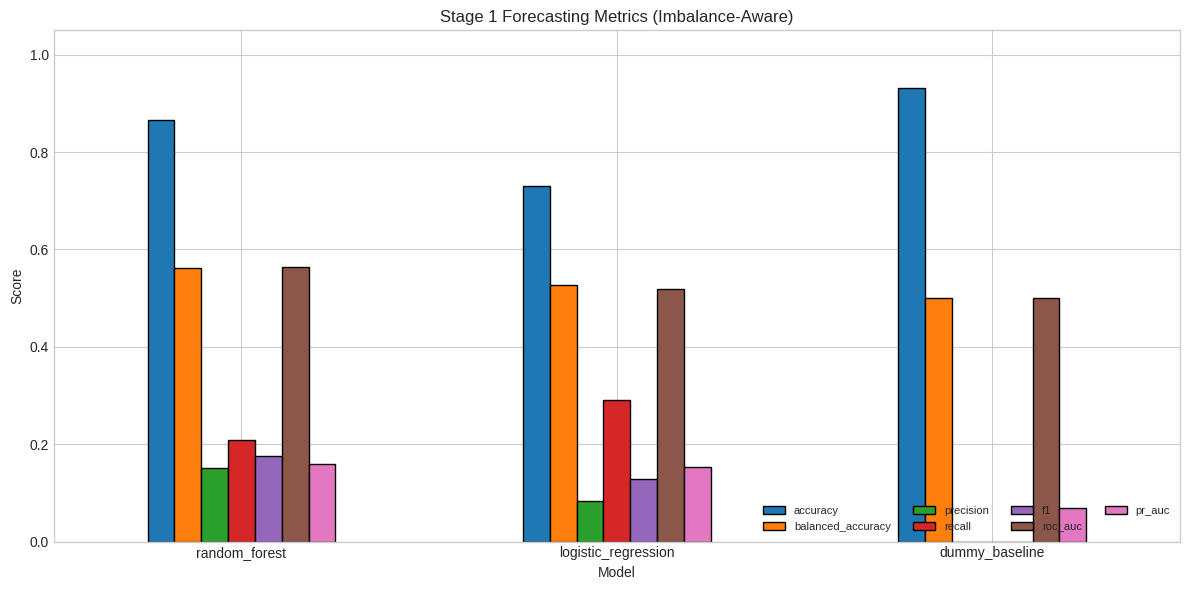

In [10]:
# Metric comparison plot (imbalance-aware)
plot_cols = ['accuracy','balanced_accuracy','precision','recall','f1','roc_auc','pr_auc']
ax = stage1_df.set_index('model')[plot_cols].plot(kind='bar', figsize=(12,6), edgecolor='black')
ax.set_title('Stage 1 Forecasting Metrics (Imbalance-Aware)')
ax.set_ylim(0,1.05)
ax.set_ylabel('Score')
ax.set_xlabel('Model')
plt.xticks(rotation=0)
plt.legend(loc='lower right', ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


## Stage 1 Diagnostic Visuals

These plots show how well Model 1 separates high-risk windows and where it makes mistakes.

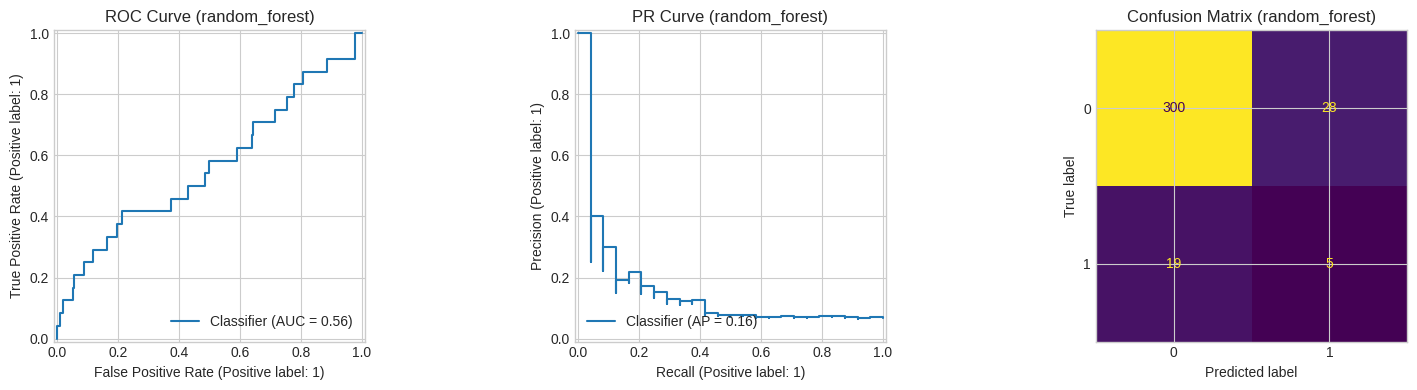

,bucket,windows,observed_rate,mean_pred
0,"(-0.001, 0.2]",261,0.053640,0.097941
1,"(0.2, 0.4]",55,0.072727,0.256713
2,"(0.4, 0.6]",27,0.148148,0.544996
3,"(0.6, 0.8]",9,0.222222,0.622847
4,"(0.8, 1.0]",0,NaN,NaN


In [11]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

best_name = metrics_df.iloc[0]['model']
best_obj = trained[best_name]
y_prob_best = best_obj['y_prob']
y_pred_best = best_obj['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(16,4))
RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=axes[0])
axes[0].set_title(f'ROC Curve ({best_name})')
PrecisionRecallDisplay.from_predictions(y_test, y_prob_best, ax=axes[1])
axes[1].set_title(f'PR Curve ({best_name})')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=axes[2], colorbar=False)
axes[2].set_title(f'Confusion Matrix ({best_name})')
plt.tight_layout()
plt.show()

risk_bins = pd.DataFrame({'p': y_prob_best, 'y': y_test.values})
risk_bins['bucket'] = pd.cut(risk_bins['p'], bins=[0,0.2,0.4,0.6,0.8,1.0], include_lowest=True)
bucket_tbl = risk_bins.groupby('bucket', observed=False).agg(windows=('y','size'), observed_rate=('y','mean'), mean_pred=('p','mean')).reset_index()
bucket_tbl


### What the model learns

For the Random Forest model, feature importance gives a simple view of which variables help separate high-attention windows from lower-attention windows. These importances should be interpreted as model behavior, not causal proof.

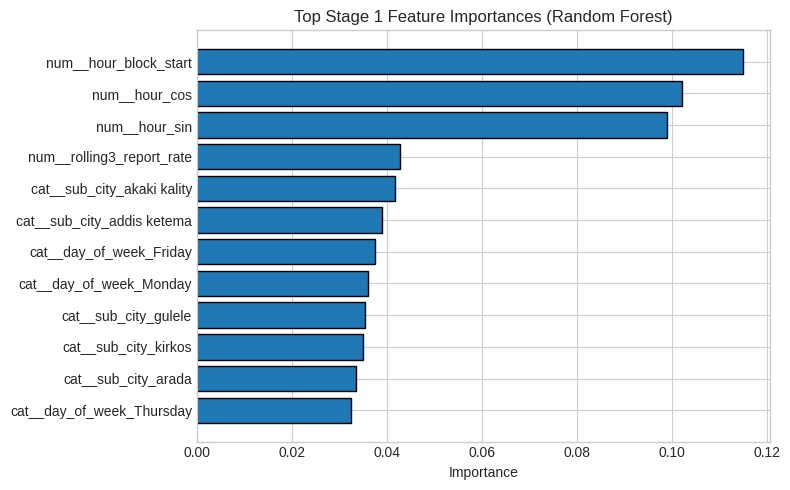

,feature,importance
0,num__hour_block_start,0.114956
2,num__hour_cos,0.102187
1,num__hour_sin,0.099073
5,num__rolling3_report_rate,0.042733
14,cat__sub_city_akaki kality,0.041774
13,cat__sub_city_addis ketema,0.038862
6,cat__day_of_week_Friday,0.037447
7,cat__day_of_week_Monday,0.035976
17,cat__sub_city_gulele,0.035334
18,cat__sub_city_kirkos,0.034933


In [12]:
if 'random_forest' in trained:
    rf_pipe = trained['random_forest']['pipe']
    try:
        feature_names = rf_pipe.named_steps['pre'].get_feature_names_out()
        importances = rf_pipe.named_steps['model'].feature_importances_
        imp_df = (pd.DataFrame({'feature': feature_names, 'importance': importances})
                  .sort_values('importance', ascending=False)
                  .head(12)
                  .sort_values('importance'))
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.barh(imp_df['feature'], imp_df['importance'], edgecolor='black')
        ax.set_title('Top Stage 1 Feature Importances (Random Forest)')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()
        display(imp_df.sort_values('importance', ascending=False))
    except Exception as e:
        print('Feature importance could not be displayed:', e)

## Stage 1 Ablation (feature contribution)

This compares safe feature sets to show what actually adds predictive signal.


In [13]:
ablation_specs = {
    'Time only': ['hour_block_start', 'day_of_week'],
    'Time + location': ['hour_block_start', 'day_of_week', 'sub_city'],
    'Time + location + history': stage1_features,
}

abl_rows = []
for name, feats in ablation_specs.items():
    X_ab = forecast_df[feats].copy()
    num_ab = [f for f in feats if f in ['hour_block_start','hour_sin','hour_cos','is_weekend','lag1_outage_reported','rolling3_report_rate']]
    cat_ab = [f for f in feats if f not in num_ab]
    pre_ab = ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_ab),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_ab)
    ])
    pipe_ab = Pipeline([
        ('pre', pre_ab),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))
    ])
    yhat = cross_val_predict(pipe_ab, X_ab, y, cv=cv, method='predict')
    ypr = cross_val_predict(pipe_ab, X_ab, y, cv=cv, method='predict_proba')[:, 1]
    abl_rows.append({
        'Model version': name,
        'Features': ', '.join(feats),
        'F1': round(f1_score(y, yhat, zero_division=0), 4),
        'PR-AUC': round(average_precision_score(y, ypr), 4),
    })

ablation_df = pd.DataFrame(abl_rows)
display(ablation_df)

,Model version,Features,F1,PR-AUC
0,Time only,"hour_block_start, day_of_week",0.1069,0.0535
1,Time + location,"hour_block_start, day_of_week, sub_city",0.1071,0.0665
2,Time + location + history,"hour_block_start, hour_sin, hour_cos, day_of_w...",0.1048,0.0743


In [14]:
# Calibration / probability buckets for best model (by F1)
best_name = stage1_df.iloc[0]['model']
best_obj = trained[best_name]
prob = best_obj['y_prob']
cal_df = pd.DataFrame({'y_true': y_test.values, 'p': prob})
cal_df['bucket'] = pd.cut(cal_df['p'], bins=[0,0.2,0.4,0.6,0.8,1.0], include_lowest=True)
cal_tbl = cal_df.groupby('bucket', observed=False).agg(
    windows=('y_true','size'),
    observed_report_rate=('y_true','mean'),
    mean_predicted_risk=('p','mean')
).reset_index()

print('Best Stage 1 model:', best_name)
cal_tbl

print('High score note: results reflect community-report signal quality, not official utility outage truth.')


Best Stage 1 model: random_forest
High score note: results reflect community-report signal quality, not official utility outage truth.


In [15]:
# Time-based validation split (credibility check)
# Refit logistic on the same chronological split using the Stage 1 preprocessing
Xtr, ytr = X_train.copy(), y_train.copy()
Xte, yte = X_test.copy(), y_test.copy()

pipe_t = Pipeline([('pre', pre), ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))])
pipe_t.fit(Xtr, ytr)
prob = pipe_t.predict_proba(Xte)[:,1]
thr_t = best_f1_threshold(ytr, pipe_t.predict_proba(Xtr)[:,1])
pred = (prob >= thr_t).astype(int)

print('Time split train rows:', len(Xtr), 'test rows:', len(Xte), 'threshold:', round(float(thr_t),4))
print('Time-split metrics (logistic):')
print({
    'accuracy': round(accuracy_score(yte,pred),4),
    'balanced_accuracy': round(balanced_accuracy_score(yte,pred),4),
    'precision': round(precision_score(yte,pred,zero_division=0),4),
    'recall': round(recall_score(yte,pred,zero_division=0),4),
    'f1': round(f1_score(yte,pred,zero_division=0),4),
    'roc_auc': round(roc_auc_score(yte,prob),4),
    'pr_auc': round(average_precision_score(yte,prob),4)
})


Time split train rows: 1232 test rows: 352 threshold: 0.5814
Time-split metrics (logistic):
{'accuracy': 0.7301, 'balanced_accuracy': np.float64(0.5269), 'precision': 0.0824, 'recall': 0.2917, 'f1': 0.1284, 'roc_auc': np.float64(0.5179), 'pr_auc': np.float64(0.1536)}


## Main findings

1. **The problem is local and measurable.** The project uses 198 anonymous community outage events from Addis Ababa and turns them into 1,584 sub-city/time-window records across 11 sub-cities and 18 dates.
2. **GridSense creates a practical risk surface.** The sub-city x time-window heatmap turns raw reports into a planning view that residents, students, and small businesses can understand.
3. **Stage 1 gives a responsible early attention signal.** After removing leakage-prone features, Stage 1 becomes a modest but credible community-report risk baseline. This is a strength: it shows what can be learned from safe features such as time, sub-city, and past reporting history without pretending to observe official grid telemetry.
4. **Stage 2 is the stronger impact layer.** Once an outage is reported, the severity classifier and duration model help estimate how disruptive the outage may be. In the current run, Stage 2 reaches an F1 score of about 0.76 for severity triage and a duration MAE of about 0.61 hours.
5. **The project shows the full Kujenga workflow.** It starts with a community problem, uses real data, cleans it, visualizes it, applies statistics/regression, builds ML models, and explains the result carefully.


## Stage 2: Conditional impact model

Stage 2 answers a different and more practical question:

> If an outage is reported, how disruptive is it likely to be?

It trains two conditional models using only reported-outage windows:

1. **Severity classifier:** predicts `high_severity_outage`.
2. **Duration regressor:** predicts `avg_duration_hours`.

This is useful for triage: not every outage report needs the same level of attention, and long/high-impact outages are more important for planning.

In [16]:
stage2 = out_df.copy()
feat2 = ['hour_block_start','sub_city','weather_condition','planned_notice_mode','confidence_score_mean']
X2 = stage2[feat2]

num2 = ['hour_block_start','confidence_score_mean']
cat2 = ['sub_city','weather_condition','planned_notice_mode']
prep2 = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num2),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),('oh', OneHotEncoder(handle_unknown='ignore'))]), cat2)
])

# severity classifier
y2 = stage2['high_severity_outage'].astype(int)
X2tr, X2te, y2tr, y2te = train_test_split(X2,y2,test_size=0.25,random_state=42,stratify=y2)
clf2 = Pipeline([('prep', prep2), ('model', RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight='balanced', random_state=42))])
clf2.fit(X2tr,y2tr)
p2 = clf2.predict(X2te)
pp2 = clf2.predict_proba(X2te)[:,1]

# duration regressor
yr = stage2['avg_duration_hours'].astype(float)
Xrtr, Xrte, yrtr, yrte = train_test_split(X2,yr,test_size=0.25,random_state=42)
reg2 = Pipeline([('prep', prep2), ('model', RandomForestRegressor(n_estimators=300, random_state=42))])
reg2.fit(Xrtr,yrtr)
yrhat = reg2.predict(Xrte)

print('Stage 2 severity metrics:')
print({
    'accuracy': round(accuracy_score(y2te,p2),4),
    'balanced_accuracy': round(balanced_accuracy_score(y2te,p2),4),
    'precision': round(precision_score(y2te,p2,zero_division=0),4),
    'recall': round(recall_score(y2te,p2,zero_division=0),4),
    'f1': round(f1_score(y2te,p2,zero_division=0),4),
    'roc_auc': round(roc_auc_score(y2te,pp2),4),
    'pr_auc': round(average_precision_score(y2te,pp2),4)
})
print('Stage 2 duration metrics:')
print({'mae': round(mean_absolute_error(yrte,yrhat),4), 'r2': round(r2_score(yrte,yrhat),4)})


Stage 2 severity metrics:
{'accuracy': 0.6667, 'balanced_accuracy': np.float64(0.5938), 'precision': 0.7222, 'recall': 0.8125, 'f1': 0.7647, 'roc_auc': np.float64(0.7109), 'pr_auc': np.float64(0.859)}
Stage 2 duration metrics:
{'mae': 0.6128, 'r2': 0.0333}


## Why this matters locally

GridSense can help Addis Ababa residents and small businesses in three practical ways:

1. **Preparation:** identify higher-risk time windows for charging devices, saving work, or planning backup power.
2. **Awareness:** show where outage reports are concentrated across sub-cities and times.
3. **Data collection:** reveal where community reporting coverage is weak and needs improvement.

The goal is not to replace official utility communication. The goal is to organize community experience into a useful local planning signal.


## Responsible scope

GridSense is designed as a community decision-support prototype.

What the current system can do well:

- organize real community reports,
- show local patterns across sub-cities and time windows,
- estimate a reported-outage risk signal,
- triage reported outages by likely impact,
- show what data is most valuable for a stronger future system.

What it should not be used for:

- replacing official utility announcements,
- claiming perfect knowledge of all outages,
- making emergency decisions without verification.

This responsible scope makes the project useful without overstating the evidence.

## From final project to deployable local tool

This final project is a strong first version of GridSense. The same structure can scale into a real community system:

1. continue collecting anonymous outage reports,
2. add optional confirmed no-outage check-ins,
3. connect real weather data for every 3-hour window,
4. add official planned interruption notices where available,
5. deploy a simple dashboard showing risk surfaces and impact summaries,
6. keep the dataset public only in anonymized, structured form.

The important point is that GridSense already demonstrates the core pipeline: **community data -> modelling -> local insight -> planning support**.

## Final conclusion

GridSense is a local AI/data science project for electricity reliability in Addis Ababa. It begins from a real daily problem: outages affect students, households, online workers, and small businesses. Instead of using a generic dataset, I collected anonymous community outage reports and transformed them into a structured 3-hour sub-city community-report window dataset.

Using 198 community outage events, GridSense creates 1,584 sub-city/time-window records across 11 sub-cities and 18 dates. The project produced two useful modelling layers. **Stage 1** estimates the probability that an outage report will be captured for a given sub-city and time window. This creates a community-based early attention signal for planning. **Stage 2** estimates the likely severity and duration of reported outages; in the current run, the severity model achieves an F1 score of about 0.76 and the duration model reaches a mean absolute error of about 0.61 hours.

The key result is that community outage reports can be turned into a privacy-aware local intelligence tool. The model is not claiming to be official utility telemetry. It is a community-based risk and impact system that helps organize local experience into actionable planning insight.

For Kujenga, this project demonstrates the full workflow: choosing a local problem, collecting real data, protecting privacy, cleaning and restructuring the dataset, visualizing patterns, applying hypothesis testing and regression, building machine-learning models, and ending with a practical conclusion. GridSense shows how AI can be used not only for abstract prediction, but for helping people in a city prepare for everyday infrastructure disruptions.
